# Preprocessing Data (NO<sub>2</sub> Semarang)

Pada khasus ini data di processing dengan 2 cara menangani data **missing value** dan membuat data menjadi **supervised** 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## 1.1 Menangani Missing Value

Untuk menjaga kontinuitas data deret waktu (time series) dan memastikan model prediksi dapat belajar dengan baik dari pola historis, nilai NO₂ yang hilang akan ditangani menggunakan metode interpolasi.

Metode interpolasi linier (`linear interpolation`) dipilih karena:

- Dapat memperkirakan nilai hilang berdasarkan tren perubahan sebelum dan sesudah tanggal yang kosong.

- Cocok untuk data lingkungan yang memiliki perubahan relatif halus dari hari ke hari.

- Tidak mengubah struktur temporal dataset, sehingga tetap menjaga urutan kronologis data.

### Contoh Data

In [4]:
new_df = pd.read_csv('../data/data-copernicus/timeseries.csv')
new_df = new_df.sort_values(by='date').reset_index(drop=True)
new_df['date'] = pd.to_datetime(new_df['date']).dt.date
new_df

,date,feature_index,NO2
0,2023-12-31,0,NaN
1,2024-01-01,0,NaN
2,2024-01-02,0,NaN
3,2024-01-03,0,NaN
4,2024-01-04,0,0.000015
...,...,...,...
117,2024-04-26,0,NaN
118,2024-04-27,0,NaN
119,2024-04-28,0,0.000050
120,2024-04-29,0,0.000047


C:\Users\USERB-PC\AppData\Local\Temp\ipykernel_5604\1809610530.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


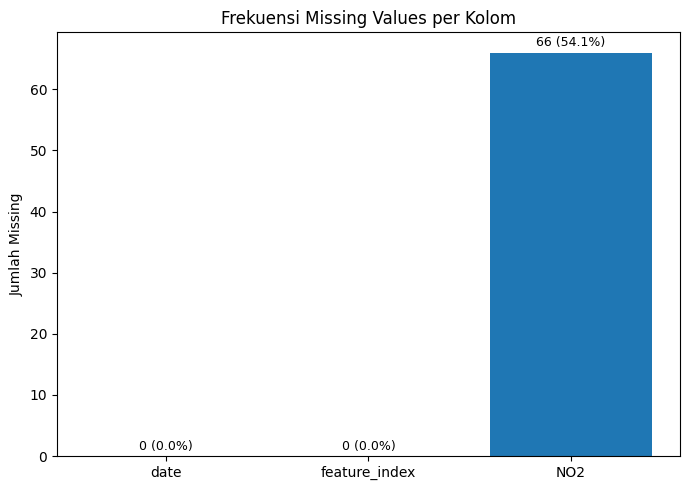

,Missing Count,Missing Percent (%)
date,0,0.0
feature_index,0,0.0
NO2,66,54.1


In [5]:
missing_count = new_df.isnull().sum()
missing_percent = (missing_count / len(new_df)) * 100

fig, ax = plt.subplots(figsize=(7,5))

bars = ax.bar(missing_count.index, missing_count)

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table


In [6]:
new_df = pd.Series(new_df['NO2'].values, index=new_df['date'], name='NO2')
new_df = new_df.interpolate(method='linear').bfill()
new_df = pd.DataFrame(new_df).reset_index()
new_df.to_csv("../data/data-copernicus/timeseries_cleaned.csv")
new_df

,date,NO2
0,2023-12-31,0.000015
1,2024-01-01,0.000015
2,2024-01-02,0.000015
3,2024-01-03,0.000015
4,2024-01-04,0.000015
...,...,...
117,2024-04-26,0.000049
118,2024-04-27,0.000050
119,2024-04-28,0.000050
120,2024-04-29,0.000047


In [7]:
missing_count = new_df.isnull().sum()
missing_percent = (missing_count / len(new_df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table


,Missing Count,Missing Percent (%)
date,0,0.0
NO2,0,0.0


Setelah dilakukan proses interpolasi linier pada kolom NO₂, hasil pemeriksaan ulang terhadap data menunjukkan bahwa seluruh nilai yang hilang telah berhasil terisi.

Dengan demikian, dataset kini bersih dari missing value dan siap digunakan untuk tahap selanjutnya, yaitu pemodelan prediksi konsentrasi NO₂ menggunakan pendekatan **K-Nearest Neighbors (KNN) Regression.**

## 1.2 Convert Supervised Learning

Dalam proyek ini, dilakukan proses konversi data time series menjadi bentuk supervised learning menggunakan Python.
Konversi ini bertujuan agar data time series dapat digunakan untuk model prediksi berbasis machine learning seperti regresi atau neural network.

Pada dasarnya, data time series hanya berisi nilai urutan waktu, sedangkan supervised learning membutuhkan pasangan input (X) dan output (y).
Oleh karena itu, proses konversi dilakukan dengan cara menggeser nilai waktu sebelumnya menjadi fitur (lag features).

Dalam kasus ini saya bereksperiment 2 - 5 hari sebelum nya menjadi fitur 

### Langkah - Langkah


In [5]:
new_df = pd.read_csv("../data/data-copernicus/timeseries_cleaned.csv")

#### Menginisialisasi day 2 - 5

In [17]:
day2 = new_df
day3 = new_df
day4 = new_df
day5 = new_df

#### Membuat data supervised menggunakan t1, t2

In [30]:
day2 = day2.drop(columns=['date'])
n = 2

for i in range(1, n + 1):
    names = f"t{i}"
    day2[names] = day2['NO2'].shift(i)

day2 = day2.dropna().reset_index(drop=True)
day2

,NO2,t1,t2
0,0.000015,0.000015,0.000015
1,0.000015,0.000015,0.000015
2,0.000015,0.000015,0.000015
3,0.000039,0.000015,0.000015
4,0.000050,0.000039,0.000015
...,...,...,...
115,0.000049,0.000048,0.000048
116,0.000050,0.000049,0.000048
117,0.000050,0.000050,0.000049
118,0.000047,0.000050,0.000050


### Supervised Multi-step Forecasting lag 2

In [11]:
day2 = day2.drop(columns=['date'])

n = 2
for i in range(1, n + 1):
    day2[f"t{i}"] = day2['NO2'].shift(i)

for j in range(1, 3):  
    day2[f"NO2_t+{j}"] = day2['NO2'].shift(-j)

day2 = day2.dropna().reset_index(drop=True)
day2 = day2.drop(columns=["NO2"])
day2.to_csv("../data/data-copernicus/day2_multi.csv")
day2

,Unnamed: 0,t1,t2,NO2_t+1,NO2_t+2
0,2,0.000015,0.000015,0.000015,0.000015
1,3,0.000015,0.000015,0.000015,0.000039
2,4,0.000015,0.000015,0.000039,0.000050
3,5,0.000015,0.000015,0.000050,0.000061
4,6,0.000039,0.000015,0.000061,0.000071
...,...,...,...,...,...
113,115,0.000047,0.000047,0.000048,0.000049
114,116,0.000048,0.000047,0.000049,0.000050
115,117,0.000048,0.000048,0.000050,0.000050
116,118,0.000049,0.000048,0.000050,0.000047


#### Membuat data supervised menggunakan t1, t2, t3

In [ ]:
day3 = day3.drop(columns=['date'])
n = 3

for i in range(1, n + 1):
    names = f"t{i}"
    day3[names] = day3['NO2'].shift(i)

day3 = day3.dropna().reset_index(drop=True)
day3

,NO2,t1,t2,t3
0,0.000015,0.000015,0.000015,0.000015
1,0.000015,0.000015,0.000015,0.000015
2,0.000039,0.000015,0.000015,0.000015
3,0.000050,0.000039,0.000015,0.000015
4,0.000061,0.000050,0.000039,0.000015
...,...,...,...,...
114,0.000049,0.000048,0.000048,0.000047
115,0.000050,0.000049,0.000048,0.000048
116,0.000050,0.000050,0.000049,0.000048
117,0.000047,0.000050,0.000050,0.000049


### Supervised Multi-step Forecasting lag 3

In [12]:

day3 = day3.drop(columns=['date'])

# Buat lag untuk fitur (t1, t2, t3)
n = 3
for i in range(1, n + 1):
    day3[f"t{i}"] = day3['NO2'].shift(i)

# Buat lead untuk label (t+1, t+2)
for j in range(1, 3):  
    day3[f"NO2_t+{j}"] = day3['NO2'].shift(-j)

# Hapus nilai kosong
day3 = day3.dropna().reset_index(drop=True)
day3 = day3.drop(columns=["NO2"])
day3.to_csv("../data/data-copernicus/day3_multi.csv")
day3

,Unnamed: 0,t1,t2,t3,NO2_t+1,NO2_t+2
0,3,0.000015,0.000015,0.000015,0.000015,0.000039
1,4,0.000015,0.000015,0.000015,0.000039,0.000050
2,5,0.000015,0.000015,0.000015,0.000050,0.000061
3,6,0.000039,0.000015,0.000015,0.000061,0.000071
4,7,0.000050,0.000039,0.000015,0.000071,0.000082
...,...,...,...,...,...,...
112,115,0.000047,0.000047,0.000046,0.000048,0.000049
113,116,0.000048,0.000047,0.000047,0.000049,0.000050
114,117,0.000048,0.000048,0.000047,0.000050,0.000050
115,118,0.000049,0.000048,0.000048,0.000050,0.000047


#### Membuat data supervised menggunakan t1, t2, t3, t4

In [32]:
day4 = day4.drop(columns=['date'])
n = 4

for i in range(1, n + 1):
    names = f"t{i}"
    day4[names] = day4['NO2'].shift(i)

day4 = day4.dropna().reset_index(drop=True)
day4

,NO2,t1,t2,t3,t4
0,0.000015,0.000015,0.000015,0.000015,0.000015
1,0.000039,0.000015,0.000015,0.000015,0.000015
2,0.000050,0.000039,0.000015,0.000015,0.000015
3,0.000061,0.000050,0.000039,0.000015,0.000015
4,0.000071,0.000061,0.000050,0.000039,0.000015
...,...,...,...,...,...
113,0.000049,0.000048,0.000048,0.000047,0.000047
114,0.000050,0.000049,0.000048,0.000048,0.000047
115,0.000050,0.000050,0.000049,0.000048,0.000048
116,0.000047,0.000050,0.000050,0.000049,0.000048


### Supervised Multi-step Forecasting lag 4

In [19]:

day4 = day4.drop(columns=['date'])

# Buat lag untuk fitur (t1, t2, t3)
n = 4
for i in range(1, n + 1):
    day4[f"t{i}"] = day4['NO2'].shift(i)

# Buat lead untuk label (t+1, t+2)
for j in range(1, 3):  
    day4[f"NO2_t+{j}"] = day4['NO2'].shift(-j)

# Hapus nilai kosong
day4 = day4.dropna().reset_index(drop=True)
day4 = day4.drop(columns=["NO2"])
day4.to_csv("../data/data-copernicus/day4_multi.csv")
day4

,Unnamed: 0,t1,t2,t3,t4,NO2_t+1,NO2_t+2
0,4,0.000015,0.000015,0.000015,0.000015,0.000039,0.000050
1,5,0.000015,0.000015,0.000015,0.000015,0.000050,0.000061
2,6,0.000039,0.000015,0.000015,0.000015,0.000061,0.000071
3,7,0.000050,0.000039,0.000015,0.000015,0.000071,0.000082
4,8,0.000061,0.000050,0.000039,0.000015,0.000082,0.000064
...,...,...,...,...,...,...,...
111,115,0.000047,0.000047,0.000046,0.000045,0.000048,0.000049
112,116,0.000048,0.000047,0.000047,0.000046,0.000049,0.000050
113,117,0.000048,0.000048,0.000047,0.000047,0.000050,0.000050
114,118,0.000049,0.000048,0.000048,0.000047,0.000050,0.000047


#### Membuat data supervised menggunakan t1, t2, t3, t4, t5

In [14]:
day5 = day5.drop(columns=['date'])
# new_df
n = 5

for i in range(1, n + 1):
    names = f"t{i}"
    day5[names] = day5['NO2'].shift(i)

day5 = day5.dropna().reset_index(drop=True)
day5

,Unnamed: 0,NO2,t1,t2,t3,t4,t5
0,5,0.000039,0.000015,0.000015,0.000015,0.000015,0.000015
1,6,0.000050,0.000039,0.000015,0.000015,0.000015,0.000015
2,7,0.000061,0.000050,0.000039,0.000015,0.000015,0.000015
3,8,0.000071,0.000061,0.000050,0.000039,0.000015,0.000015
4,9,0.000082,0.000071,0.000061,0.000050,0.000039,0.000015
...,...,...,...,...,...,...,...
112,117,0.000049,0.000048,0.000048,0.000047,0.000047,0.000046
113,118,0.000050,0.000049,0.000048,0.000048,0.000047,0.000047
114,119,0.000050,0.000050,0.000049,0.000048,0.000048,0.000047
115,120,0.000047,0.000050,0.000050,0.000049,0.000048,0.000048


### Supervised Multi-step Forecasting lag 5

In [18]:

day5 = day5.drop(columns=['date'])

# Buat lag untuk fitur (t1, t2, t3)
n = 5
for i in range(1, n + 1):
    day5[f"t{i}"] = day5['NO2'].shift(i)

# Buat lead untuk label (t+1, t+2)
for j in range(1, 3):  
    day5[f"NO2_t+{j}"] = day5['NO2'].shift(-j)

# Hapus nilai kosong
day5 = day5.dropna().reset_index(drop=True)
day5 = day5.drop(columns=["NO2"])
day5.to_csv("../data/data-copernicus/day5_multi.csv")
day5

,Unnamed: 0,t1,t2,t3,t4,t5,NO2_t+1,NO2_t+2
0,5,0.000015,0.000015,0.000015,0.000015,0.000015,0.000050,0.000061
1,6,0.000039,0.000015,0.000015,0.000015,0.000015,0.000061,0.000071
2,7,0.000050,0.000039,0.000015,0.000015,0.000015,0.000071,0.000082
3,8,0.000061,0.000050,0.000039,0.000015,0.000015,0.000082,0.000064
4,9,0.000071,0.000061,0.000050,0.000039,0.000015,0.000064,0.000046
...,...,...,...,...,...,...,...,...
110,115,0.000047,0.000047,0.000046,0.000045,0.000023,0.000048,0.000049
111,116,0.000048,0.000047,0.000047,0.000046,0.000045,0.000049,0.000050
112,117,0.000048,0.000048,0.000047,0.000047,0.000046,0.000050,0.000050
113,118,0.000049,0.000048,0.000048,0.000047,0.000047,0.000050,0.000047
